# 02 · 확률에서 손실 만들기

**이번 질문:** MSE·BCE·cross-entropy는 어떤 관측을 잘 설명하려고 만든 식이며, 그 식을 어떻게 안정적인 코드로 옮길까요?

[00](00_math_to_numpy.ipynb)의 배열과 [01](01_gradients_and_learning.ipynb)의 미분을 사용합니다. 확률 기호는 이 노트북에서 다시 설명합니다.

- 1–4절: 확률·밀도·조건부 확률·기댓값을 작은 숫자로 계산합니다.
- 5–8절: 관측의 우도에서 MSE·BCE·softmax CE를 만들고 미분합니다.
- 9–10절: 분류기를 학습하고, 직접 작성한 손실·기울기를 검사합니다.

핵심 함수와 검산은 모두 본문에 있습니다. 각 예제의 출력부터 예상하고 실행한 뒤, 마지막 문제에서 수식과 함수를 직접 복원해 보세요.

[셀 실행 안내](../../README.md) · [전체 경로](../../docs/CURRICULUM.md) · [그림 보조 코드](../../src/utils/probability_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "utils" / "plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src.utils import setup_plots, plot_gradcheck
from src import check_function
from src.utils.probability_plots import (
    plot_discrete, plot_density, plot_estimates, plot_likelihood,
    plot_loss_curves, plot_classifier,
)
setup_plots()
np.set_printoptions(precision=5, suppress=True)
print("NumPy", np.__version__, "· 확률과 손실 준비 완료")

NumPy 2.3.5 · 확률과 손실 준비 완료


## 1. 확률과 기댓값: 가능한 값에 가중치를 줍니다

확률변수 $A$는 결과에 따라 달라지는 숫자입니다. 여기서는 $A\in\{0,1,2\}$이고 각 값의 확률이 $(0.2,0.5,0.3)$입니다.
확률은 음수가 아니며 가능한 값 전체의 확률을 합하면 1입니다. 사건 $A\ge1$은 1 또는 2가 나오는 경우이므로 확률은 $0.5+0.3=0.8$입니다.

기댓값(expectation)은 **가능한 값의 확률 가중합**입니다.

$$\mathbb E[f(A)]=\sum_i p_i f(a_i),\qquad \mathbb E[A]=0(0.2)+1(0.5)+2(0.3)=1.1.$$

`values`, `probabilities`는 같은 `(3,)` 모양입니다. 값과 확률을 같은 인덱스로 짝지어 곱하고 합합니다.
기댓값 1.1이 실제로 가능한 결과일 필요는 없습니다.
`values >= 1`은 각 원소를 비교해 `[False, True, True]`라는 Boolean 배열을 만듭니다.
`probabilities[values >= 1]`은 True인 위치의 확률만 꺼내는 마스크 인덱싱입니다.

In [2]:
def expectation(values, probabilities):
    values = np.asarray(values, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    assert values.ndim == 1 and values.shape == probabilities.shape
    assert np.all(probabilities >= 0) and np.isclose(probabilities.sum(), 1)
    return np.sum(values * probabilities)

In [3]:
values = np.array([0., 1., 2.])
probabilities = np.array([0.2, 0.5, 0.3])
manual_sum = 0.0
for i in range(len(values)):
    manual_sum += probabilities[i] * values[i]
mean = expectation(values, probabilities)
variance = expectation((values - mean) ** 2, probabilities)
np.testing.assert_allclose([mean, variance], [1.1, 0.49])
np.testing.assert_allclose(mean, manual_sum)
print("P(A >= 1) =", probabilities[values >= 1].sum())
print("E[A] =", mean, "· Var(A) =", variance)

P(A >= 1) = 0.8
E[A] = 1.1 · Var(A) = 0.49


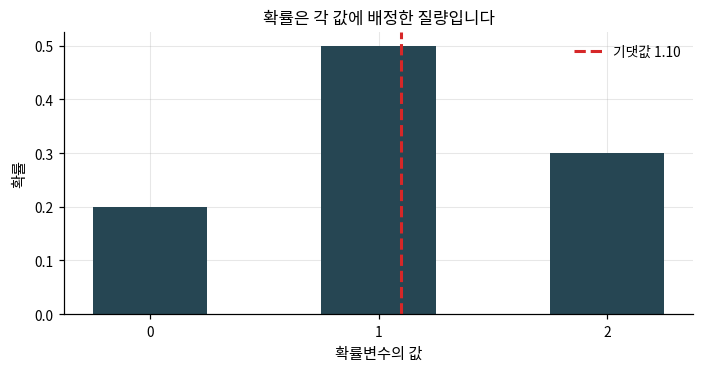

In [4]:
plot_discrete(values, probabilities, mean)

분산 $\operatorname{Var}(A)=\mathbb E[(A-\mathbb E[A])^2]$도 새로운 평균 방식이 아니라, 제곱 편차에 같은 확률 가중합을 적용한 것입니다. 뒤의 Monte Carlo와 미니배치도 무엇에 대해 평균내는지를 먼저 정합니다.

## 2. 결합·주변·조건부 확률: 합하는 축과 고정하는 축

두 이진 변수 $A,B$의 결합확률 $P(A=a,B=b)$를 아래 행렬에 저장합니다. **행은 A, 열은 B**입니다.

$$P=\begin{bmatrix}0.3&0.2\\0.1&0.4\end{bmatrix}.$$

- $P(A=a)=\sum_b P(A=a,B=b)$: B축인 `axis=1`을 합합니다.
- $P(B=b)=\sum_a P(A=a,B=b)$: A축인 `axis=0`을 합합니다.
- $P(B=b\mid A=a)=P(A=a,B=b)/P(A=a)$: A가 주어진 행의 합을 1로 만듭니다. 분모가 양수인 행에서 정의합니다.

In [5]:
joint = np.array([[0.3, 0.2], [0.1, 0.4]])
p_a = joint.sum(axis=1)                 # (2,): A의 주변확률
p_b = joint.sum(axis=0)                 # (2,): B의 주변확률
b_given_a = joint / p_a[:, None]        # (2, 2): 각 행을 그 행의 확률로 나눔
np.testing.assert_allclose(joint.sum(), 1)
np.testing.assert_allclose(b_given_a, [[0.6, 0.4], [0.2, 0.8]])
np.testing.assert_allclose(b_given_a.sum(axis=1), 1)
a1_given_b1 = joint[1, 1] / p_b[1]
bayes = b_given_a[1, 1] * p_a[1] / p_b[1]
np.testing.assert_allclose([a1_given_b1, bayes], [2/3, 2/3])
print("P(A):", p_a, "P(B):", p_b)
print("행별 P(B | A):\n", b_given_a)
print("P(A=1 | B=1):", a1_given_b1)

P(A): [0.5 0.5] P(B): [0.4 0.6]
행별 P(B | A):
 [[0.6 0.4]
 [0.2 0.8]]
P(A=1 | B=1): 0.6666666666666666


같은 결합확률을 두 방향으로 나누면 Bayes 식이 나옵니다.
$P(A\mid B)=P(B\mid A)P(A)/P(B)$입니다. 이 예제에서 $P(B=1\mid A=1)=0.8$과 $P(B=1)=0.6$은 다르므로 독립이 아닙니다.
분류기는 앞으로 $P_\theta(Y\mid X)$를 계산합니다. 입력 X를 고정했을 때 라벨 Y에 배정할 확률을 파라미터 $\theta$로 정합니다.

## 3. 연속값: 확률밀도는 넓이로 확률이 됩니다

연속 변수 U가 구간 $[0,0.25]$에서 균일하다면 밀도는 구간 안에서 4, 밖에서 0입니다.
밀도 $p(u)$의 높이는 1보다 클 수 있지만, 전체 면적은 1이어야 합니다.

$$P(a\le U\le b)=\int_a^b p(u)\,du,\qquad P(0.05\le U\le0.15)=4(0.15-0.05)=0.4.$$

이 적분은 작은 막대의 `높이 * 폭`을 더해 근사할 수 있습니다.
아래의 `(조건1) & (조건2)`는 원소별로 두 조건이 모두 참인지 검사합니다.
`np.where(조건, 참일 때 값, 거짓일 때 값)`는 각 위치에서 조건에 따라 값을 선택합니다. 밀도를 갖는 연속 분포에서는 정확히 한 점일 확률이 0입니다. `p(0.1)=4`는 그 한 점의 확률이 아닙니다.

In [6]:
def uniform_density(x, low=0.0, high=0.25):
    x = np.asarray(x, dtype=float)
    assert high > low
    return np.where((low <= x) & (x <= high), 1 / (high - low), 0.0)

In [7]:
edges = np.linspace(0, 0.25, 1001)       # 구간 경계 1001개
midpoints = (edges[:-1] + edges[1:]) / 2 # 막대 중심 1000개
widths = np.diff(edges)                 # 이웃 경계의 차이 = 각 막대 폭
density = uniform_density(midpoints)
interval = (midpoints >= 0.05) & (midpoints <= 0.15)
total_area = np.sum(density * widths)
interval_probability = np.sum(density[interval] * widths[interval])
np.testing.assert_allclose([total_area, interval_probability], [1, 0.4])
print("밀도 높이", density[0], "· 전체 면적", total_area, "· 구간 확률", interval_probability)

밀도 높이 4.0 · 전체 면적 1.0 · 구간 확률 0.39999999999999997


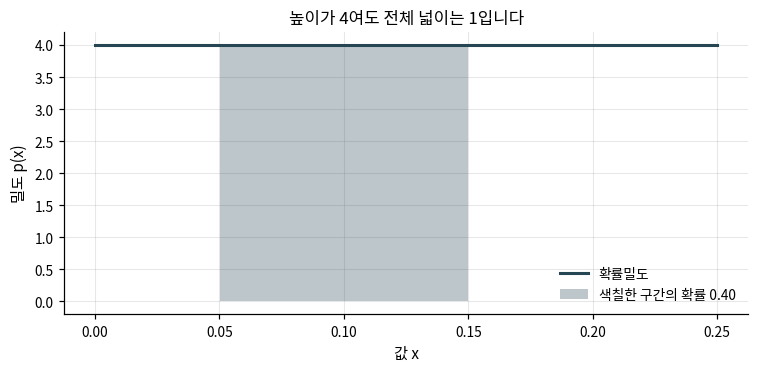

In [8]:
plot_density(midpoints, density, interval, interval_probability)

앞의 확률표에서는 값을 **합해서** 1이 되었고, 밀도에서는 **면적을 합해서** 1이 됩니다. 곧 가우스 밀도로 회귀 관측을 설명할 때 이 차이가 다시 필요합니다.

## 4. Monte Carlo: 표본 평균으로 기댓값을 추정합니다

분포에서 독립적으로 뽑은 표본 $a^{(1)},\ldots,a^{(M)}$에 대해

$$\mathbb E[f(A)]\approx\frac1M\sum_{m=1}^M f(a^{(m)}).$$

왼쪽은 모든 가능한 값에 확률을 곱하는 계산이고, 오른쪽은 실제로 뽑힌 값들의 평균입니다.
`rng.choice(..., p=...)`는 지정한 확률로 값을 뽑습니다. `seed`는 이 예제를 다시 실행할 때 같은 표본을 만들기 위한 설정입니다.
한 번의 추정 오차가 표본 수에 따라 계속 감소한다고 보장하지는 않습니다.

In [9]:
rng = np.random.default_rng(202)
samples = rng.choice(values, size=5000, p=probabilities)
counts = np.arange(1, len(samples) + 1)
running_mean = np.cumsum(samples) / counts  # cumsum: 앞에서부터 누적 합
sample_mean = samples.mean()
# 손계산으로 구한 분산에서 이 표본 평균의 표준편차를 계산합니다.
standard_error = np.sqrt(variance / len(samples))
np.testing.assert_allclose(running_mean[-1], sample_mean)
print(f"정확한 E[A]={mean:.4f}, 이번 표본 평균={sample_mean:.4f}, 표준오차={standard_error:.4f}")

정확한 E[A]=1.1000, 이번 표본 평균=1.1046, 표준오차=0.0099


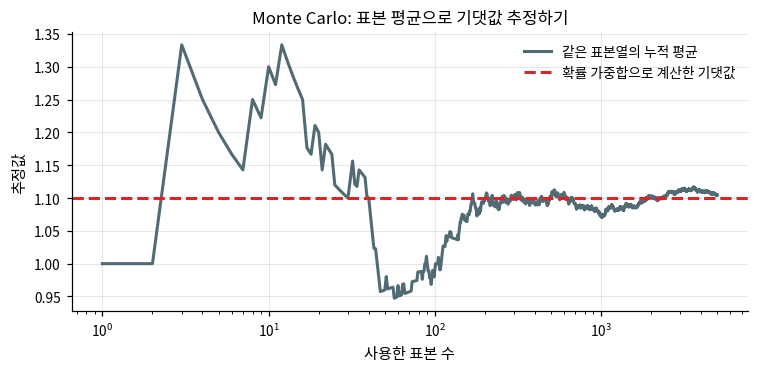

In [10]:
plot_estimates(counts, running_mean, mean)

학습 데이터의 평균 손실도 비슷한 형태입니다. 표본 손실의 평균으로 데이터가 나오는 분포의 기대 손실을 추정합니다. 유한한 학습 데이터에서 잘 맞는 것과 새 데이터에서도 잘 맞는 것은 구분해야 합니다.

## 5. 관측에서 목적함수로: 우도와 음의 로그우도

### 먼저, 곱·지수·로그의 기호를 연결합니다

$\prod_{n=1}^N a_n$은 $a_1a_2\cdots a_N$처럼 곱한다는 뜻입니다. 합 기호 $\sum$의 곱 버전입니다.
$\exp(u)=e^u$는 밑이 $e\approx2.71828$인 지수함수이고, 자연로그 $\log x$는 **e를 몇 제곱하면 x가 되는가**를 나타냅니다. 따라서 $e^{\log x}=x$이고 로그의 입력은 양수입니다.

$e^{u+v}=e^u e^v$이므로 $\log(ab)=\log a+\log b$입니다. 여기서 곱을 합으로 바꿀 수 있습니다. 또한 $\log(a^r)=r\log a$로 거듭제곱을 계수로 꺼낼 수 있습니다.
이 노트북에 필요한 두 미분 규칙은 다음과 같습니다.

$$\frac{d}{du}e^u=e^u,\qquad \frac{d}{dx}\log x=\frac1x.$$

e는 $\lim_{h\to0}(e^h-1)/h=1$이 되는 밑입니다. 따라서 지수의 변화율은
$\lim_{h\to0}(e^{u+h}-e^u)/h=e^u$입니다.
$e^{\log x}=x$를 연쇄법칙으로 미분하면 $e^{\log x}(\log x)'=1$이므로 두 번째 규칙이 나옵니다.
코드의 `np.exp`·`np.log`가 이 두 함수이며, `np.log1p(t)`는 작은 t에서도 $\log(1+t)$를 정확히 계산하는 함수입니다.

In [11]:
np.testing.assert_allclose(np.exp(np.log(3.0)), 3.0)
np.testing.assert_allclose(np.log(2.0 * 3.0), np.log(2.0) + np.log(3.0))
eps = 1e-6
x = 2.0
log_derivative = (np.log(x + eps) - np.log(x - eps)) / (2 * eps)
exp_derivative = (np.exp(x + eps) - np.exp(x - eps)) / (2 * eps)
np.testing.assert_allclose(log_derivative, 1/x, rtol=1e-8)
np.testing.assert_allclose(exp_derivative, np.exp(x), rtol=1e-8)
print("log의 변화율", log_derivative, "· exp의 변화율", exp_derivative)

log의 변화율 0.5000000000143778 · exp의 변화율 7.3890560989831044


### 고정한 관측에 파라미터 후보를 대입합니다

독립인 동전 관측이 `1, 1, 0, 1`이었다고 합시다. 관측은 고정하고 성공확률 후보 $\theta$를 바꿉니다. 이 네 관측의 우도는 $\theta^3(1-\theta)$입니다.

$$L(\theta)=\prod_{n=1}^N \theta^{y_n}(1-\theta)^{1-y_n}.$$

이를 우도(likelihood)라고 부릅니다. $P_\theta(Y)$는 고정된 $\theta$에서 Y에 대한 분포이고, $L(\theta)$는 **주어진 관측에 대한 파라미터 후보의 점수**입니다. 우도를 $\theta$에 대해 합하거나 적분해서 1로 만들 필요는 없습니다.

양수에서 로그는 단조증가하므로 우도 최대화와 로그우도 최대화는 같은 후보를 선택합니다. 곱을 로그의 합으로 바꾸고 음수를 붙여 **최소화할 손실**로 씁니다.

$$J(\theta)=-\frac1N\log L(\theta)=-\frac1N\sum_n[y_n\log\theta+(1-y_n)\log(1-\theta)].$$

상수 후보인 이 동전 문제에서는 $J'(\theta)=-\bar y/\theta+(1-\bar y)/(1-\theta)=0$을 풀면 $\theta=\bar y=0.75$입니다. 모든 관측이 같은 라벨이면 최적 후보는 경계 0 또는 1입니다.

In [12]:
def bernoulli_nll(probability, targets):
    probability = np.asarray(probability, dtype=float)
    targets = np.asarray(targets, dtype=float)
    assert np.all((probability > 0) & (probability < 1))
    assert np.all((targets == 0) | (targets == 1))
    return -np.mean(targets * np.log(probability)
                    + (1 - targets) * np.log1p(-probability))

In [13]:
coin = np.array([1., 1., 0., 1.])
theta_grid = np.linspace(0.01, 0.99, 99)
likelihoods = np.array([np.prod(t ** coin * (1-t) ** (1-coin)) for t in theta_grid])
nlls = np.array([bernoulli_nll(t, coin) for t in theta_grid])
np.testing.assert_allclose(theta_grid[np.argmax(likelihoods)], 0.75)
np.testing.assert_allclose(theta_grid[np.argmin(nlls)], 0.75)
np.testing.assert_allclose(bernoulli_nll(0.5, coin), np.log(2))
print("최대 우도 후보", theta_grid[np.argmax(likelihoods)])
print("log(곱)와 log의 합:", np.log(np.prod(0.75 ** coin * 0.25 ** (1-coin))),
      -len(coin) * bernoulli_nll(0.75, coin))

최대 우도 후보 0.75
log(곱)와 log의 합: -2.2493405784752336 -2.249340578475233


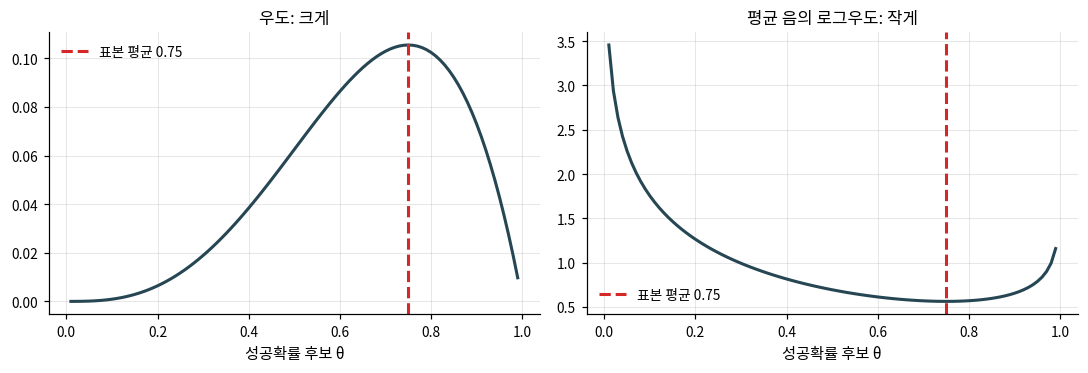

In [14]:
plot_likelihood(theta_grid, likelihoods, nlls, coin.mean())

곱하는 수가 많으면 부동소수점에서 우도가 0으로 작아질 수 있습니다. 다음 셀에서는 경고를 만들지 않고 그 차이를 직접 확인합니다.

In [15]:
with np.errstate(under="ignore"):
    tiny_likelihood = np.prod(np.full(2000, 0.5))
log_likelihood = np.log(0.5) * 2000
assert tiny_likelihood == 0 and np.isfinite(log_likelihood)
print("2000개 확률의 곱:", tiny_likelihood, "· 로그의 합:", log_likelihood)

2000개 확률의 곱: 0.0 · 로그의 합: -1386.2943611198905


## 6. 가우스 관측 모형에서 MSE를 얻습니다

예측 평균 $\mu_\theta(x)$ 주변에 일정한 표준편차 $\sigma>0$의 가우스 잡음이 있다고 가정합니다.
관측들은 입력을 조건으로 독립이라고 둡니다.

$$p_\theta(y\mid x)=\frac1{\sqrt{2\pi}\sigma}\exp\left[-\frac{(y-\mu_\theta(x))^2}{2\sigma^2}\right].$$

밀도에 음의 로그를 적용하면 $-\log p=\frac12\log(2\pi\sigma^2)+(y-\mu)^2/(2\sigma^2)$입니다.
스칼라 출력 총 M개에 대해 평균내면

$$J=\tfrac12\log(2\pi\sigma^2)+\frac1{2\sigma^2M}\sum_i(\mu_i-y_i)^2,
\qquad\frac{\partial J}{\partial\mu_i}=\frac{\mu_i-y_i}{\sigma^2M}.$$

**고정된 $\sigma$**에서는 첫 항이 파라미터와 무관하므로 MSE와 같은 최적 평균을 찾습니다. $\sigma$도 학습한다면 첫 항을 버릴 수 없습니다.
01의 손실은 $\sigma=1$일 때 상수항을 뺀 **절반 MSE**였습니다. 통상적인 MSE에 1/2를 곱한 표기를 계속 사용합니다.

In [16]:
def gaussian_nll(prediction, target, sigma=1.0):
    assert sigma > 0 and prediction.shape == target.shape
    residual = prediction - target
    return 0.5 * np.log(2 * np.pi * sigma**2) + 0.5 * np.mean(residual**2) / sigma**2


def gaussian_mean_gradient(prediction, target, sigma=1.0):
    return (prediction - target) / (prediction.size * sigma**2)

In [17]:
prediction = np.array([[1.], [2.], [4.]])
target = np.array([[0.], [2.], [3.]])
half_mse = 0.5 * np.mean((prediction - target)**2)
np.testing.assert_allclose(half_mse, 1/3)
np.testing.assert_allclose(gaussian_nll(prediction, target), 0.5*np.log(2*np.pi) + 1/3)
gaussian_error = check_function(
    lambda mu: np.array(gaussian_nll(mu, target, sigma=0.7)),
    lambda dout, mu: dout * gaussian_mean_gradient(mu, target, sigma=0.7),
    prediction, dout=np.array(1.0), verbose=True, name="Gaussian NLL → 평균",
)
print("절반 MSE", half_mse, "· Gaussian NLL", gaussian_nll(prediction, target))

[gradcheck] Gaussian NLL → 평균
  ok   dx  rel_err = 3.596e-10
절반 MSE 0.3333333333333333 · Gaussian NLL 1.252271866538006


## 7. Bernoulli 모형에서 BCE와 logit 기울기를 얻습니다

동전의 고정 확률 대신 입력별 확률 $p_n=\sigma(z_n)$를 사용합니다.
logit $z$는 실수 전체를 가질 수 있는 점수이며, sigmoid가 이를 0과 1 사이의 확률로 바꿉니다.

$$p=\sigma(z)=\frac1{1+e^{-z}},\quad\frac{dp}{dz}=p(1-p),\quad
\ell=-y\log p-(1-y)\log(1-p).$$

연쇄법칙을 한 줄씩 연결하면

$$\frac{\partial\ell}{\partial p}=-\frac yp+\frac{1-y}{1-p},\qquad
\frac{\partial\ell}{\partial z}=\left(-\frac yp+\frac{1-y}{1-p}\right)p(1-p)=p-y.$$

sigmoid의 미분도 $p=(1+e^{-z})^{-1}$에 연쇄법칙을 적용하면
$p'=e^{-z}/(1+e^{-z})^2=p(1-p)$로 얻습니다.
평균 손실에서는 전체 스칼라 라벨 수 M으로 나눕니다. 아래 예제는 `(N,1)`이므로 M=N입니다.

확률을 먼저 계산해 `log(p)`에 넣으면 큰 logit에서 반올림으로 p가 0 또는 1이 될 수 있습니다.
같은 식을 logit으로 정리합니다.

$$\ell=\log(1+e^z)-yz
=\max(z,0)-yz+\log(1+e^{-|z|}).$$

`np.logaddexp(0, z)`는 $\log(e^0+e^z)$를 안정적으로 계산합니다. `np.log1p(t)`는 $\log(1+t)$를 작은 t에서도 정확히 계산하는 함수입니다.

In [18]:
def sigmoid(logits):
    logits = np.asarray(logits, dtype=float)
    exp_negative_abs = np.exp(-np.abs(logits))
    return np.where(logits >= 0,
                    1 / (1 + exp_negative_abs),
                    exp_negative_abs / (1 + exp_negative_abs))


def bce_with_logits(logits, targets):
    assert logits.shape == targets.shape
    loss = np.mean(np.logaddexp(0.0, logits) - targets * logits)
    gradient = (sigmoid(logits) - targets) / targets.size
    return float(loss), gradient

In [19]:
logits = np.array([[0.], [np.log(3.)]])
labels = np.array([[0.], [1.]])
bce_loss, bce_gradient = bce_with_logits(logits, labels)
np.testing.assert_allclose(sigmoid(logits).ravel(), [0.5, 0.75])
np.testing.assert_allclose(bce_loss, (-np.log(0.5) - np.log(0.75))/2)
np.testing.assert_allclose(bce_gradient, [[0.25], [-0.125]])
np.testing.assert_allclose(bce_loss, bernoulli_nll(sigmoid(logits), labels))
bce_error = check_function(
    lambda z: np.array(bce_with_logits(z, labels)[0]),
    lambda dout, z: dout * bce_with_logits(z, labels)[1],
    logits, dout=np.array(1.0), verbose=True, name="BCE → logits",
)
extreme_z = np.array([[-1000.], [1000.]])
extreme_y = np.array([[1.], [0.]])
extreme_loss, extreme_gradient = bce_with_logits(extreme_z, extreme_y)
assert np.isfinite(extreme_loss) and np.all(np.isfinite(extreme_gradient))
np.testing.assert_allclose(extreme_loss, 1000.0)
print("BCE", bce_loss, "· 기울기", bce_gradient.ravel())
print("극단적인 오답 logit의 손실", extreme_loss, "· 기울기", extreme_gradient.ravel())

[gradcheck] BCE → logits
  ok   dx  rel_err = 6.989e-11
BCE 0.49041462650586315 · 기울기 [ 0.25  -0.125]
극단적인 오답 logit의 손실 1000.0 · 기울기 [-0.5  0.5]


In [20]:
z_grid = np.linspace(-8, 8, 201)
loss_curves = {"y=0": np.logaddexp(0, z_grid), "y=1": np.logaddexp(0, z_grid)-z_grid}
gradient_curves = {"y=0": sigmoid(z_grid), "y=1": sigmoid(z_grid)-1}

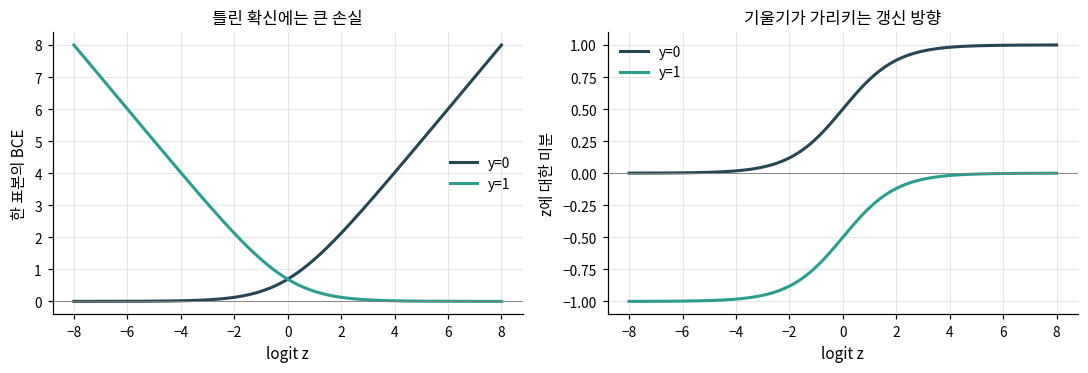

In [21]:
plot_loss_curves(z_grid, loss_curves, gradient_curves)

y=1인데 z가 큰 음수이면 미분은 약 -1입니다. 경사하강에서 이 음수를 빼면 z가 커집니다. 확률이 정답 쪽으로 움직이는지 부호로 검산할 수 있습니다.
아래 검산에서 `dout=1`을 명시한 것은 스칼라 손실 자체를 미분한다는 뜻입니다.

## 8. Categorical 모형에서 softmax CE를 얻습니다

한 샘플이 K개 클래스 중 **정확히 하나**에 속한다면 logit 행렬 $Z\in\mathbb R^{N\times K}$를 사용합니다.

$$P_{nk}=\frac{e^{Z_{nk}}}{\sum_j e^{Z_{nj}}},\qquad
J=-\frac1N\sum_n\log P_{n,y_n}.$$

정답을 one-hot 행렬 T로 쓰면 $T_{nk}=1[k=y_n]$이며 $J=-\frac1N\sum_{n,k}T_{nk}\log P_{nk}$입니다.
한 행의 확률을 합하면 1입니다. **클래스 축은 합하고, 샘플 축은 평균냅니다. 분모는 NK가 아니라 N입니다.**

한 행에서 $\ell=\log\sum_j e^{z_j}-z_y$이므로

$$\frac{\partial\ell}{\partial z_k}=\frac{e^{z_k}}{\sum_j e^{z_j}}-1[k=y]=p_k-t_k.$$

따라서 `dZ=(P-T)/N`입니다. 여러 개의 독립 이진 라벨을 예측하는 다중라벨 문제라면 각 출력에 BCE를 쓰며, 위의 한 클래스 선택 모형과 구분합니다.

수치 계산에서는 행의 최댓값 m을 빼서 $\log P_k=(z_k-m)-\log\sum_j e^{z_j-m}$로 만듭니다. 확률은 공통 상수를 빼도 같으며 지수에 큰 양수가 들어가지 않습니다.

In [22]:
def log_softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    return shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))


def softmax_cross_entropy(logits, targets):
    N, K = logits.shape
    assert targets.shape == (N,) and np.issubdtype(targets.dtype, np.integer)
    assert np.all((0 <= targets) & (targets < K))
    log_probabilities = log_softmax(logits)
    probabilities = np.exp(log_probabilities)
    rows = np.arange(N)  # rows[n]과 targets[n]을 한 쌍으로 선택합니다.
    loss = -log_probabilities[rows, targets].mean()
    gradient = probabilities.copy()
    gradient[rows, targets] -= 1
    gradient /= N
    return float(loss), gradient

In [23]:
class_logits = np.array([[0., 0., 0.], [np.log(2), 0., 0.]])
class_targets = np.array([2, 0])
ce_loss, ce_gradient = softmax_cross_entropy(class_logits, class_targets)
class_probabilities = np.exp(log_softmax(class_logits))
np.testing.assert_allclose(class_probabilities, [[1/3, 1/3, 1/3], [0.5, 0.25, 0.25]])
np.testing.assert_allclose(ce_loss, (np.log(3)+np.log(2))/2)
np.testing.assert_allclose(ce_gradient, [[1/6, 1/6, -1/3], [-0.25, 0.125, 0.125]])
np.testing.assert_allclose(ce_gradient.sum(axis=1), 0, atol=1e-15)
np.testing.assert_allclose(log_softmax(class_logits + 10000), log_softmax(class_logits), atol=1e-11)
ce_error = check_function(
    lambda z: np.array(softmax_cross_entropy(z, class_targets)[0]),
    lambda dout, z: dout * softmax_cross_entropy(z, class_targets)[1],
    class_logits, dout=np.array(1.), verbose=True, name="softmax CE → logits",
)
print("클래스 확률:\n", class_probabilities)
print("CE", ce_loss, "· dZ:\n", ce_gradient)

[gradcheck] softmax CE → logits
  ok   dx  rel_err = 1.398e-10
클래스 확률:
 [[0.33333 0.33333 0.33333]
 [0.5     0.25    0.25   ]]
CE 0.8958797346140275 · dZ:
 [[ 0.16667  0.16667 -0.33333]
 [-0.25     0.125    0.125  ]]


<Axes: ylabel='상대오차'>

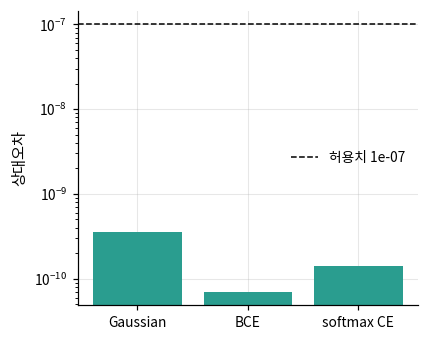

In [24]:
plot_gradcheck({"Gaussian": gaussian_error, "BCE": bce_error, "softmax CE": ce_error})

검산한 것은 같은 손실의 수식과 코드 미분이 작은 입력에서 일치하는지입니다. 데이터에 적절한 관측 모형인지까지 수치미분이 판단해 주지는 않습니다.

## 9. 목적함수를 실제 분류 학습에 연결합니다

작은 이진 분류 문제에서 $z_n=x_n w+b$, $p_n=\sigma(z_n)$로 놓습니다.
BCE가 반환한 `dZ`에 이미 평균이 들어 있으므로 01처럼 `dW=X.T @ dZ`, `db=dZ.sum(axis=0)`를 계산합니다.

| 이름 | shape | 의미 |
|---|---|---|
| X, Y, Z | `(N, 1)` | 입력, 라벨, logit |
| W, b | `(1, 1)`, `(1,)` | 가중치, 편향 |
| dZ | `(N, 1)` | 평균 BCE의 logit 기울기 |

라벨은 이 작은 고정 예제를 이해하기 위해 직접 정했습니다. 다음 단원에서 비선형 분류를 다룹니다.

In [25]:
def train_logistic(X, Y, steps=400, learning_rate=0.2):
    W, b = np.zeros((X.shape[1], 1)), np.zeros(1)
    losses = []
    for step in range(steps + 1):
        logits = X @ W + b
        loss, dZ = bce_with_logits(logits, Y)
        losses.append(loss)
        if step == steps:
            break
        dW = X.T @ dZ
        db = dZ.sum(axis=0)
        W -= learning_rate * dW
        b -= learning_rate * db
    return W, b, np.array(losses)

In [26]:
X_train = np.array([[-2.], [-1.5], [-1.], [-0.5], [0.3], [0.8], [1.2], [2.]])
Y_train = np.array([[0.], [0.], [0.], [0.], [1.], [1.], [1.], [1.]])
W, b, training_losses = train_logistic(X_train, Y_train)
train_probabilities = sigmoid(X_train @ W + b)
accuracy = np.mean((train_probabilities >= 0.5) == Y_train)
assert training_losses[-1] < training_losses[0] / 5
assert accuracy == 1.0
print(f"학습 손실 {training_losses[0]:.6f} → {training_losses[-1]:.6f}, 학습 정확도 {accuracy:.1%}")
print("W", W.ravel(), "b", b)
curve_x = np.linspace(-2.3, 2.3, 200)[:, None]
curve_probability = sigmoid(curve_x @ W + b)

학습 손실 0.693147 → 0.043524, 학습 정확도 100.0%
W [4.48523] b [0.39428]


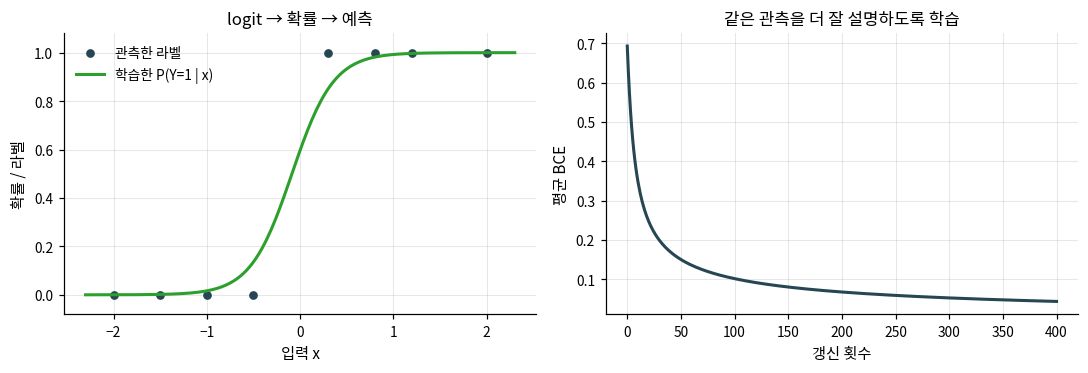

In [27]:
plot_classifier(X_train.ravel(), Y_train.ravel(), curve_x.ravel(), curve_probability.ravel(), training_losses)

여기의 정확도는 **학습에 쓴 8개 점**에서 측정했습니다. 새로운 데이터에 대한 성능을 측정한 값은 아닙니다.
또한 선형 분리 가능한 이 데이터의 BCE는 가중치 크기를 계속 늘려 더 작게 만들 수 있으므로, 유한한 최적 가중치를 찾았다고 해석하지 않습니다.
학습은 logit과 확률을 만들고, 실제 클래스 선택은 마지막의 임계값 0.5로 수행합니다.

## 10. 직접 바꾸고 검산합니다

### 연습 A · 확률과 기댓값

1절을 가리고 `my_expectation(values, probabilities)`를 직접 작성하세요. 값이 `[0, 2, 5]`, 확률이 `[0.5, 0.25, 0.25]`라면 기댓값은 1.75입니다.
아래 검사 예제 다음에 새 Code 셀을 추가하고 자신의 함수를 정의한 뒤 `check_expectation(my_expectation)`을 실행하세요.

In [28]:
def check_expectation(candidate):
    np.testing.assert_allclose(candidate(np.array([0., 2., 5.]), np.array([0.5, 0.25, 0.25])), 1.75)
    np.testing.assert_allclose(candidate(np.array([-1., 3.]), np.array([0.25, 0.75])), 2.0)
    print("기댓값 변형: 손계산과 일치합니다.")

In [29]:
check_expectation(expectation)

기댓값 변형: 손계산과 일치합니다.


### 연습 B · 클래스가 4개인 CE

`my_ce(logits, targets)`가 `(평균 손실, logit 기울기)`를 반환하도록 직접 작성하세요.
logit이 모두 0이면 각 클래스의 확률은 1/4이고, 정답의 기울기는 $(1/4-1)/N$입니다.
샘플을 두 번 복제하면 평균 손실은 같고 각 복제본의 기울기는 절반이 되어야 합니다.
새 셀에 자신의 함수를 정의한 뒤 `check_ce(my_ce)`로 확인하세요.

In [30]:
def check_ce(candidate):
    z = np.zeros((2, 4))
    y = np.array([1, 3])
    loss, grad = candidate(z, y)
    expected = np.array([[1/8, -3/8, 1/8, 1/8], [1/8, 1/8, 1/8, -3/8]])
    np.testing.assert_allclose(loss, np.log(4))
    np.testing.assert_allclose(grad, expected)
    doubled_loss, doubled_grad = candidate(np.concatenate([z, z]), np.concatenate([y, y]))
    np.testing.assert_allclose(doubled_loss, loss)
    np.testing.assert_allclose(doubled_grad[:2], grad / 2)
    uneven_z = np.array([[np.log(3.), 0., 0., 0.]])
    uneven_loss, uneven_grad = candidate(uneven_z, np.array([0]))
    np.testing.assert_allclose(uneven_loss, np.log(2))
    np.testing.assert_allclose(uneven_grad, [[-0.5, 1/6, 1/6, 1/6]])
    print("4개 클래스·배치 복제·서로 다른 logit: 손계산과 일치합니다.")

In [31]:
check_ce(softmax_cross_entropy)

4개 클래스·배치 복제·서로 다른 logit: 손계산과 일치합니다.


### 다음으로 가기 전, 네 가지를 따로 확인합니다

- **설명:** 확률과 밀도, 확률분포와 우도는 무엇이 다른가요? → 2·3·5절
- **수식:** 가우스와 Bernoulli 모형의 음의 로그우도를 직접 정리할 수 있나요? → 6·7절
- **구현:** sigmoid·BCE·log-softmax가 큰 logit에서도 계산되도록 작성할 수 있나요? → 7·8절
- **변형:** BCE의 전체 원소 평균과 CE의 샘플 평균을 구분하고, 출력·배치 크기를 바꾸어 검산했나요? → 8·10절

다음은 [03 · 퍼셉트론에서 MLP까지](03_perceptron_to_mlp.ipynb)입니다. 목적함수를 유지한 채 입력에서 logit을 만드는 구조를 바꿉니다.

참고한 저자 교재: [D2L 선형 회귀의 확률 모형](https://d2l.ai/chapter_linear-regression/linear-regression.html), [D2L softmax 회귀](https://d2l.ai/chapter_linear-classification/softmax-regression.html). 본문의 작은 숫자·검산·실험은 이 노트북에서 직접 계산합니다.